<a href="https://colab.research.google.com/github/SarthoPramanik1075/Machine-Learning-/blob/main/Heart_disease_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay

In [3]:
df=pd.read_csv('/content/heart_disease.csv')
df.sample(10)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
2022,52.0,Male,145.0,246.0,Medium,Yes,Yes,Yes,26.012273,Yes,...,No,Medium,Medium,8.642560,Low,143.0,135.0,12.960290,18.252561,No
4750,67.0,Female,150.0,156.0,NaN,No,Yes,Yes,38.978005,No,...,Yes,NaN,Low,5.927580,High,292.0,150.0,7.923753,10.465394,No
2685,57.0,Female,129.0,152.0,Medium,No,No,Yes,24.616420,Yes,...,No,NaN,Low,4.012854,High,384.0,144.0,7.863327,12.196980,No
6410,65.0,Male,146.0,255.0,Low,No,No,No,24.978456,No,...,Yes,NaN,Medium,7.499586,Low,127.0,147.0,1.354152,7.089211,No
3660,79.0,Female,158.0,240.0,Low,Yes,No,No,28.744031,No,...,Yes,Medium,Low,4.689410,Medium,212.0,125.0,10.661419,13.754375,No
6678,23.0,Male,137.0,156.0,Medium,Yes,No,No,36.162158,No,...,Yes,NaN,Low,7.892497,Low,228.0,114.0,13.424622,16.248471,No
2985,60.0,Male,165.0,289.0,High,No,No,No,30.224636,Yes,...,Yes,Low,Low,4.426636,High,392.0,85.0,10.978837,16.481874,No
7688,57.0,Male,136.0,231.0,Low,Yes,Yes,No,27.316872,Yes,...,Yes,High,Low,4.170278,Medium,238.0,141.0,12.207346,7.672209,No
5819,56.0,Male,150.0,160.0,Medium,No,Yes,Yes,29.512558,Yes,...,Yes,NaN,Medium,4.033286,Low,305.0,145.0,9.778124,18.353491,No
5414,70.0,Male,125.0,200.0,Low,No,Yes,No,33.382246,Yes,...,No,High,Medium,4.346798,Medium,152.0,135.0,13.074795,7.860227,No


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [5]:
df.isnull().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,9971.0,49.30,18.19,18.0,34.00,49.00,65.00,80.0
Blood Pressure,9981.0,149.76,17.57,120.0,134.00,150.00,165.00,180.0
Cholesterol Level,9970.0,225.43,43.58,150.0,187.00,226.00,263.00,300.0
BMI,9978.0,29.08,6.31,18.0,23.66,29.08,34.52,40.0
Sleep Hours,9975.0,6.99,1.75,4.0,5.45,7.00,8.53,10.0
Triglyceride Level,9974.0,250.73,87.07,100.0,176.00,250.00,326.00,400.0
Fasting Blood Sugar,9978.0,120.14,23.58,80.0,99.00,120.00,141.00,160.0
CRP Level,9974.0,7.47,4.34,0.0,3.67,7.47,11.26,15.0
Homocysteine Level,9980.0,12.46,4.32,5.0,8.72,12.41,16.14,20.0


In [7]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

num_cols=X.select_dtypes(include='number').columns.tolist()
cat_cols=X.select_dtypes(exclude='number').columns.tolist()

print(num_cols)
print(cat_cols)

['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']


#numerical Column Handle

In [8]:
# df[num_cols].describe().T.round(2)

In [9]:
df[num_cols].isnull().sum()

,0
Age,29
Blood Pressure,19
Cholesterol Level,30
BMI,22
Sleep Hours,25
Triglyceride Level,26
Fasting Blood Sugar,22
CRP Level,26
Homocysteine Level,20


In [10]:
#skewied
df[num_cols].skew()

,0
Age,-0.006789
Blood Pressure,0.013907
Cholesterol Level,-0.007120
BMI,-0.021342
Sleep Hours,0.000172
Triglyceride Level,0.006142
Fasting Blood Sugar,-0.008915
CRP Level,-0.004069
Homocysteine Level,0.007886


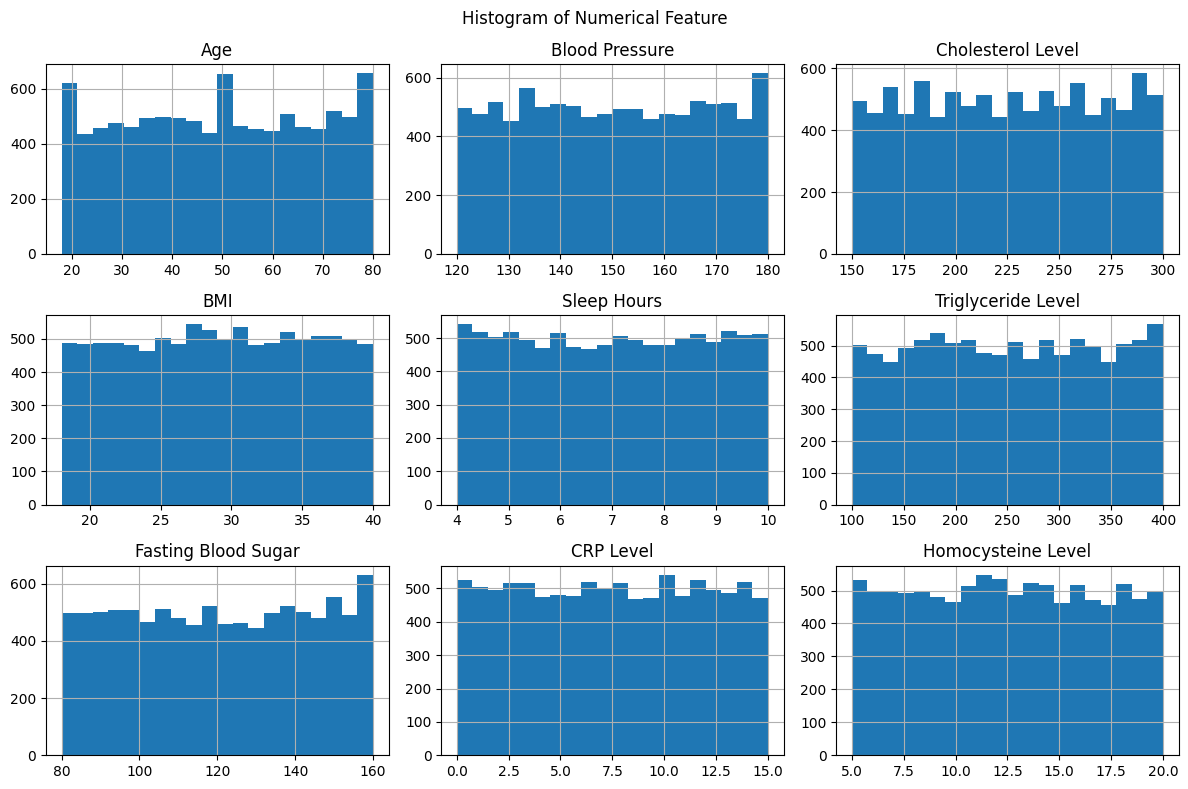

In [11]:
#Distribution Check
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle('Histogram of Numerical Feature', fontsize=12)
plt.tight_layout()

#Outlier

In [16]:
outlier_summary={}

for n in num_cols:
  Q1=df[n].quantile(0.25)
  Q3=df[n].quantile(0.75)
  IQR=Q3-Q1

  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR

  outliers=df[(df[n] < lower_bound) | (df[n] > upper_bound)]
  outlier_summary[n]=len(outliers)

outlier_df = pd.DataFrame(
  outlier_summary.items(),
  columns=['column','Number of Outliers']
).sort_values(by='Number of Outliers', ascending=False)

print(outlier_df)

                column  Number of Outliers
0                  Age                   0
1       Blood Pressure                   0
2    Cholesterol Level                   0
3                  BMI                   0
4          Sleep Hours                   0
5   Triglyceride Level                   0
6  Fasting Blood Sugar                   0
7            CRP Level                   0
8   Homocysteine Level                   0


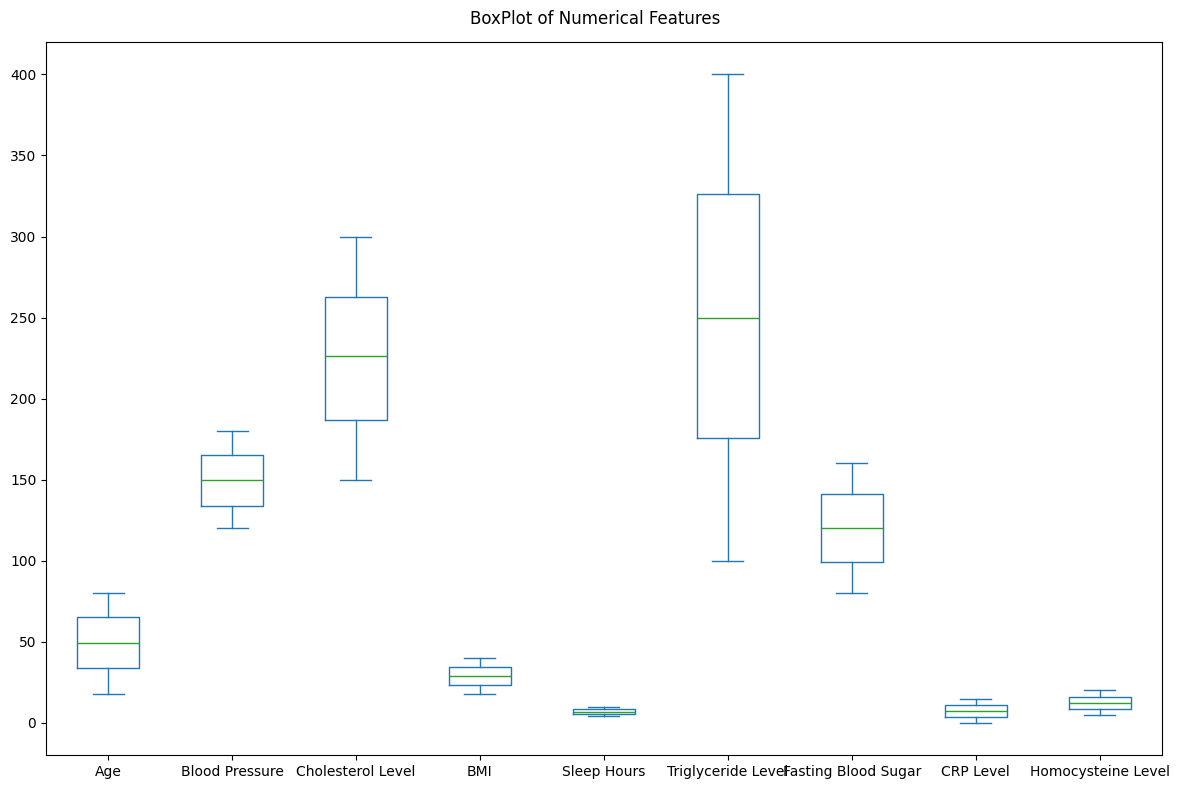

In [17]:
df[num_cols].plot(kind='box', figsize=(12,8))
plt.suptitle("BoxPlot of Numerical Features")
plt.tight_layout()


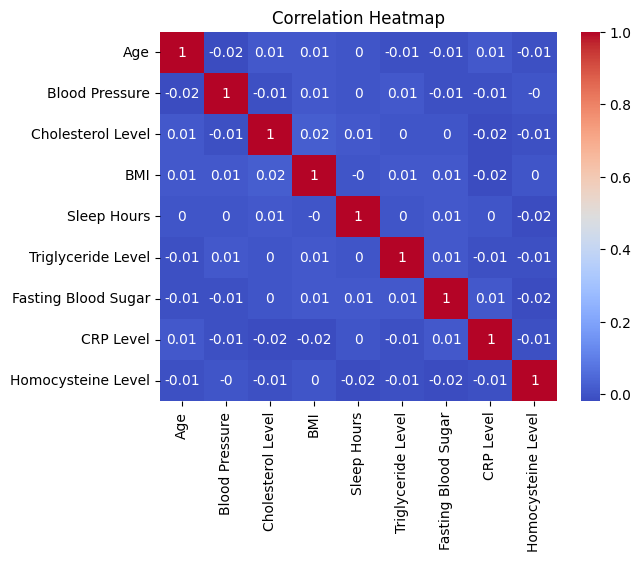

In [18]:
#correlation
sns.heatmap(df[num_cols].corr().round(2), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#Categorical Column

In [29]:
for c in cat_cols:
  print(f'Category: {c}', df[c].unique())
  print(f'Null: {c} {df[c].isnull().sum()}\n')

Category: Gender ['Male' 'Female' nan]
Null: Gender 19

Category: Exercise Habits ['High' 'Low' 'Medium' nan]
Null: Exercise Habits 25

Category: Smoking ['Yes' 'No' nan]
Null: Smoking 25

Category: Family Heart Disease ['Yes' 'No' nan]
Null: Family Heart Disease 21

Category: Diabetes ['No' 'Yes' nan]
Null: Diabetes 30

Category: High Blood Pressure ['Yes' 'No' nan]
Null: High Blood Pressure 26

Category: Low HDL Cholesterol ['Yes' 'No' nan]
Null: Low HDL Cholesterol 25

Category: High LDL Cholesterol ['No' 'Yes' nan]
Null: High LDL Cholesterol 26

Category: Alcohol Consumption ['High' 'Medium' 'Low' nan]
Null: Alcohol Consumption 2586

Category: Stress Level ['Medium' 'High' 'Low' nan]
Null: Stress Level 22

Category: Sugar Consumption ['Medium' 'Low' 'High' nan]
Null: Sugar Consumption 30



Catogory value count

In [38]:
for c in cat_cols:
  print(f'Category: {df[c].value_counts(dropna=False)}\n')

Category: Gender
Male      5003
Female    4978
NaN         19
Name: count, dtype: int64

Category: Exercise Habits
High      3372
Medium    3332
Low       3271
NaN         25
Name: count, dtype: int64

Category: Smoking
Yes    5123
No     4852
NaN      25
Name: count, dtype: int64

Category: Family Heart Disease
No     5004
Yes    4975
NaN      21
Name: count, dtype: int64

Category: Diabetes
No     5018
Yes    4952
NaN      30
Name: count, dtype: int64

Category: High Blood Pressure
Yes    5022
No     4952
NaN      26
Name: count, dtype: int64

Category: Low HDL Cholesterol
Yes    5000
No     4975
NaN      25
Name: count, dtype: int64

Category: High LDL Cholesterol
No     5036
Yes    4938
NaN      26
Name: count, dtype: int64

Category: Alcohol Consumption
NaN       2586
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64

Category: Stress Level
Medium    3387
Low       3320
High      3271
NaN         22
Name: count, dtype: int64

Category: Sugar Consumption
Low   

In [ ]:
for c in cat_cols:
  sns.countplot(data=df, x=c)
  plt.show()

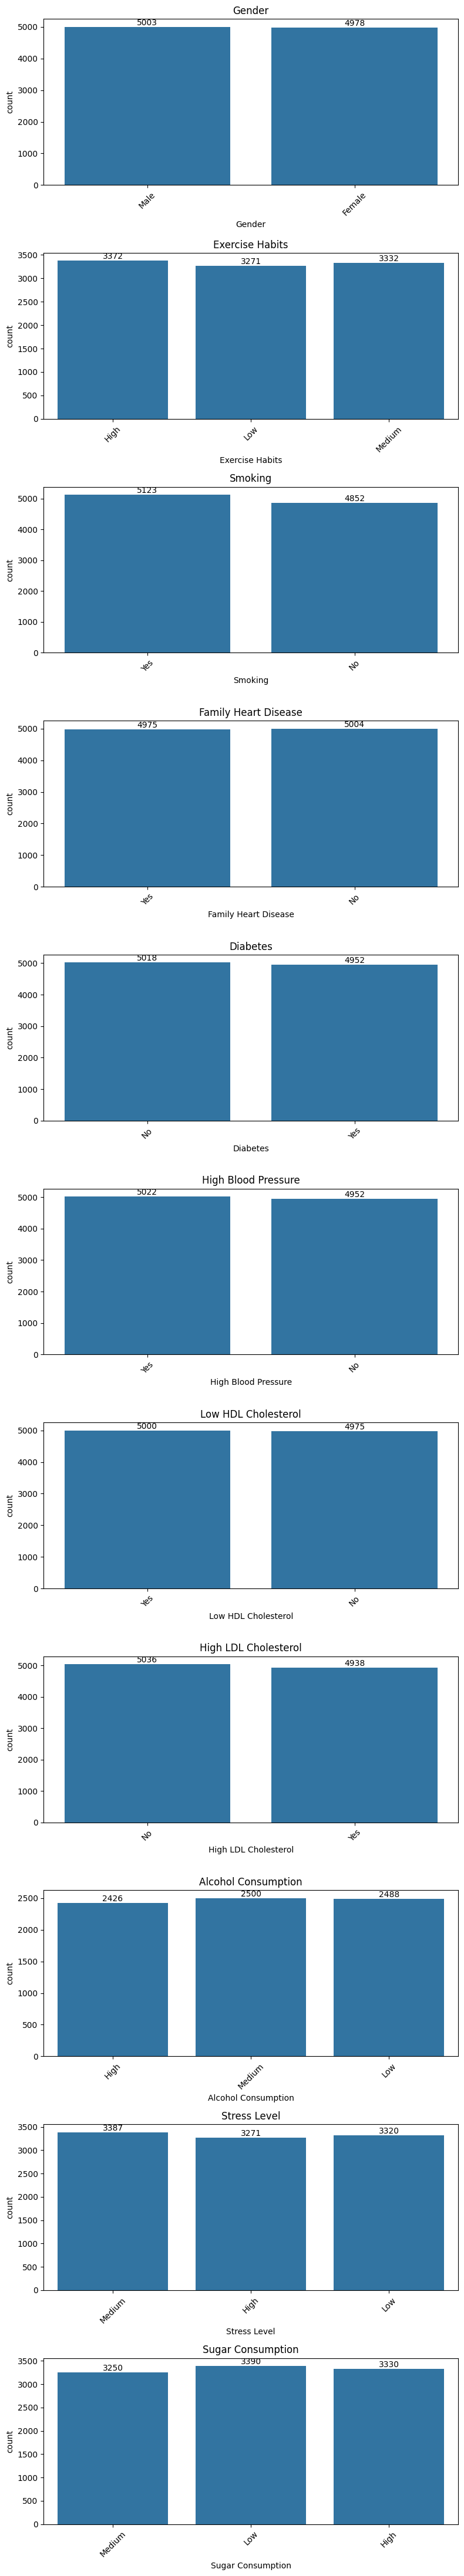

In [48]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(8, 4* len(cat_cols)))
for i, col in enumerate(cat_cols):

  ax=axes[i]
  sns.countplot(data=df, x=col, ax=ax)
  ax.set_title(col)
  ax.tick_params(axis='x', rotation=45)

  for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

#Relation with target col

In [54]:
target_cols = 'Heart Disease Status'

for c in cat_cols:
  print(f'\n{'='*60}')
  print(f'{c} vs {target_cols}')
  print('='*60)

  #row wise per
  result= pd.crosstab(
      df[c],
      df[target_cols],
      normalize='index'
  ) *100
  print(result.round(2))


Gender vs Heart Disease Status
Heart Disease Status     No    Yes
Gender                            
Female                79.31  20.69
Male                  80.63  19.37

Exercise Habits vs Heart Disease Status
Heart Disease Status     No    Yes
Exercise Habits                   
High                  79.98  20.02
Low                   80.28  19.72
Medium                79.62  20.38

Smoking vs Heart Disease Status
Heart Disease Status     No    Yes
Smoking                           
No                    80.11  19.89
Yes                   79.91  20.09

Family Heart Disease vs Heart Disease Status
Heart Disease Status     No    Yes
Family Heart Disease              
No                    79.76  20.24
Yes                   80.30  19.70

Diabetes vs Heart Disease Status
Heart Disease Status     No    Yes
Diabetes                          
No                    79.89  20.11
Yes                   80.11  19.89

High Blood Pressure vs Heart Disease Status
Heart Disease Status     No    Yes

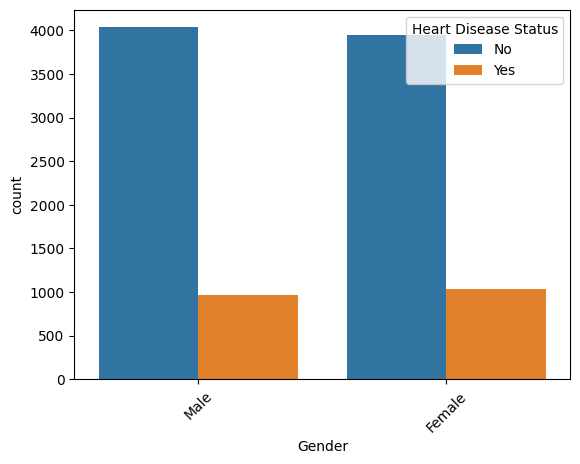

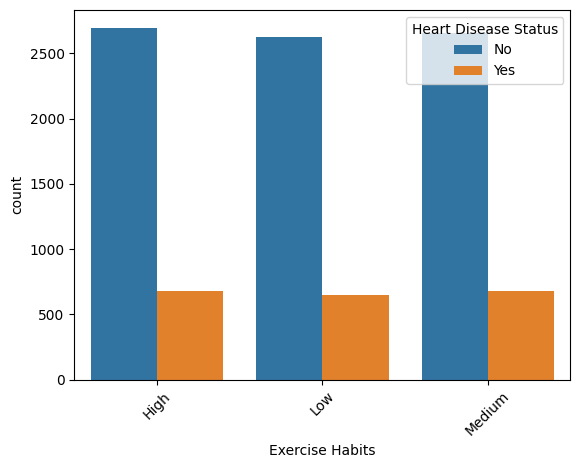

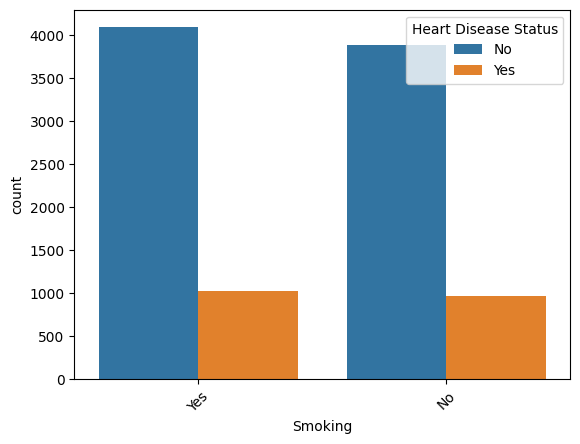

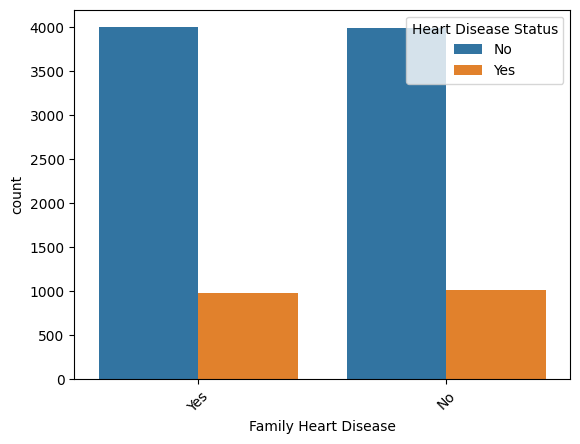

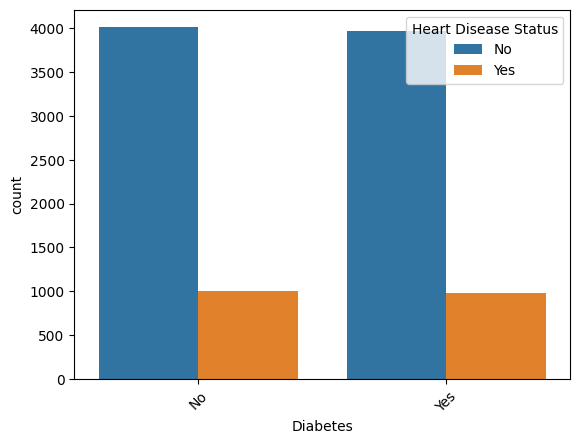

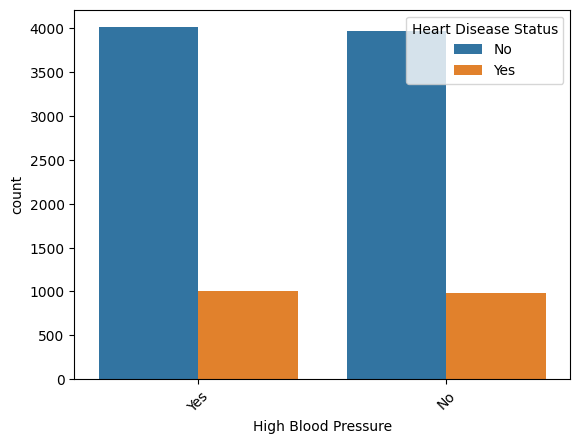

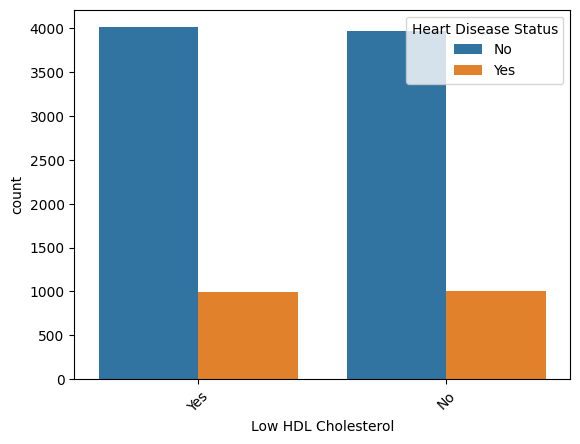

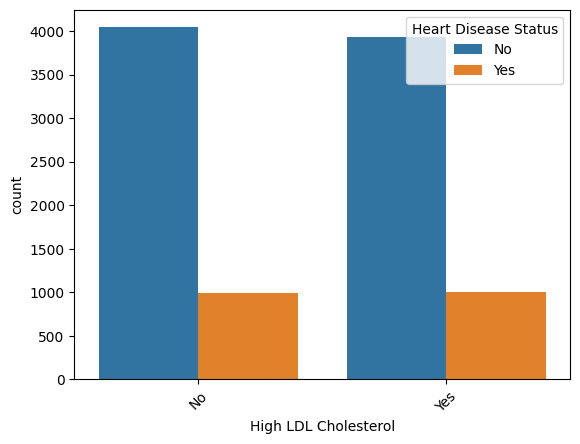

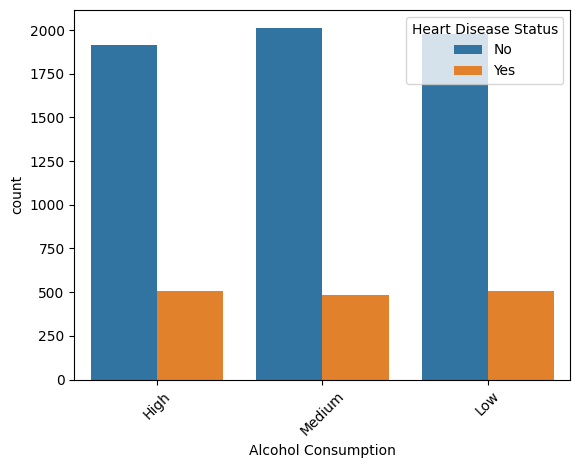

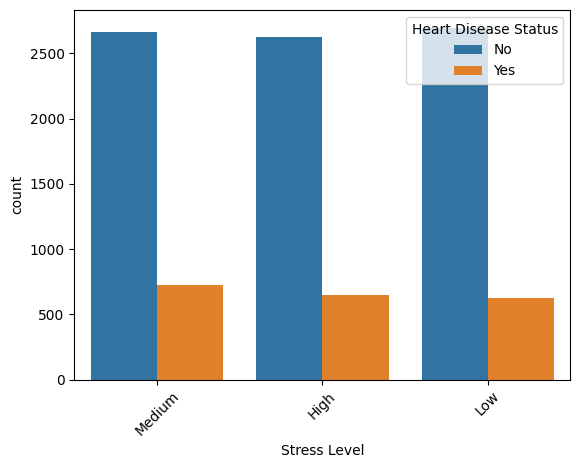

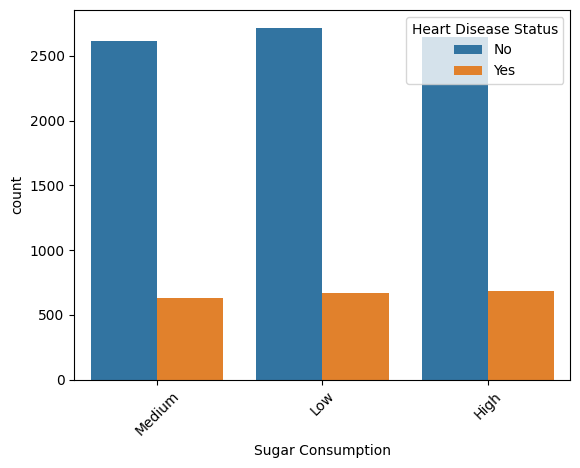

In [49]:
for c in cat_cols:
    sns.countplot(data=df, x=c, hue='Heart Disease Status')
    plt.xticks(rotation=45)
    plt.show()

#Target Col encoding

In [55]:
y = y.map(
    {
        'No':0,
        'Yes':1
    }
)

In [56]:
y

,Heart Disease Status
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,1
9997,1
9998,1


In [60]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

#Num Pipeline
# Missing Value -> Median
# Scaling -> StandardScaler

In [62]:
num_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
]
)

# Categorical Pipeline
# Missing Value -> Most Frequent
# Encoding -> OrdinalEncoder

In [63]:
cat_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))

])

#Combine Pipeline

In [64]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat',cat_pipeline, cat_cols)
])

#Full Pipeline + Model

In [112]:
trained_model={} #extra for save model logic

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
    ),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=1000,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=1,
        random_state=42
    )
}

results = []

for name, clf in models.items():

    # Full Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    #for save model
    trained_model[name]=pipeline

    # Predict
    y_pred = pipeline.predict(X_test)

    # Store Results
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    })

# Final Results Table
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by='F1 Score', ascending=False)

print(result_df)

                 Model  Accuracy  Precision  Recall  F1 Score  \
0  Logistic Regression    0.5015   0.191950   0.465  0.271731   
2        Decision Tree    0.6630   0.178404   0.190  0.184019   
4              XGBoost    0.7805   0.208955   0.035  0.059957   
3    Gradient Boosting    0.7855   0.204082   0.025  0.044543   
1        Random Forest    0.8000   0.000000   0.000  0.000000   

           Confusion Matrix  
0  [[817, 783], [214, 186]]  
2  [[1250, 350], [324, 76]]  
4   [[1547, 53], [386, 14]]  
3   [[1561, 39], [390, 10]]  
1     [[1600, 0], [400, 0]]  


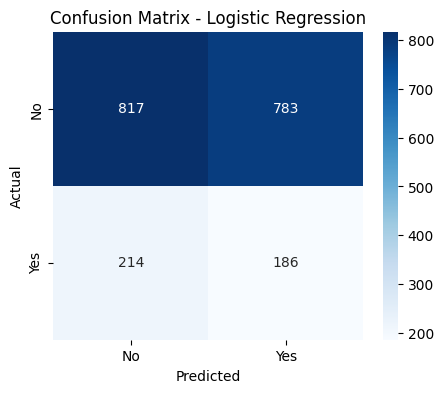

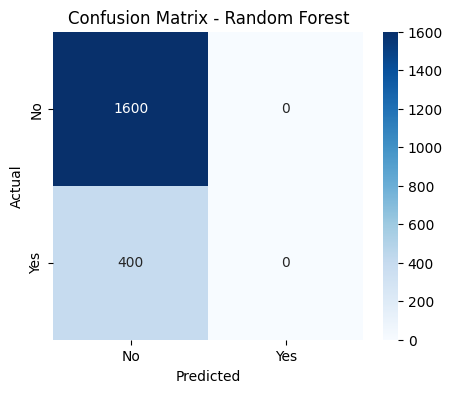

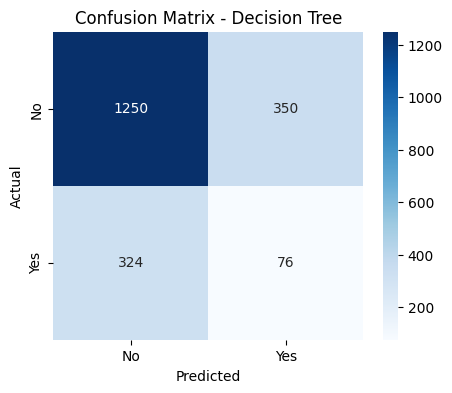

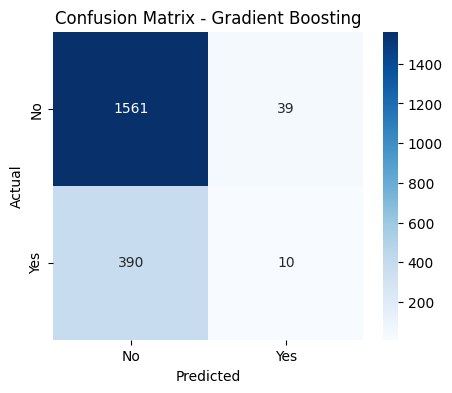

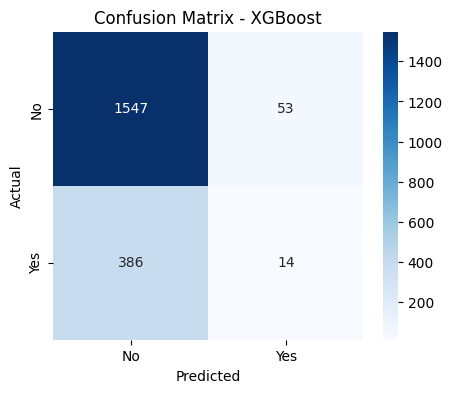

In [113]:
for name, clf in models.items():

    # Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes']
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

#Random model useless & Logistic Model Best

In [116]:

# Find Best Model Using Logic
best_model = None
best_model_name = None
best_f1_score = -1

for row in results:
    if row['F1 Score'] > best_f1_score:
        best_model_name = row['Model']
        best_row = row
        best_f1_score = row['F1 Score']

best_model=trained_model[best_model_name]

# Print Best Model Information
print("\n" + "=" * 50)
print("🏆 BEST MODEL")
print("=" * 50)
print("Model     :", best_row['Model'])
print("Accuracy  :", round(best_row['Accuracy'], 4))
print("Precision :", round(best_row['Precision'], 4))
print("Recall    :", round(best_row['Recall'], 4))
print("F1 Score  :", round(best_row['F1 Score'], 4))
print("=" * 50)


🏆 BEST MODEL
Model     : Logistic Regression
Accuracy  : 0.5015
Precision : 0.192
Recall    : 0.465
F1 Score  : 0.2717


In [117]:
import joblib
joblib.dump(best_model, 'heart_disease_model.pkl')

print("\nModel saved successfully as 'heart_disease_model.pkl'")


Model saved successfully as 'heart_disease_model.pkl'


In [118]:
# 2. Load Saved Model

loaded_model = joblib.load('heart_disease_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [119]:
# ==========================================
# 3. Test on New Patient Data
# ==========================================
import pandas as pd

# নতুন রোগীর তথ্য (কলাম নাম অবশ্যই X-এর সাথে একই হতে হবে)
new_patient = pd.DataFrame([{
    'Age': 55,
    'Gender': 'Male',
    'Blood Pressure': 145,
    'Cholesterol Level': 240,
    'Exercise Habits': 'Low',
    'Smoking': 'Yes',
    'Family Heart Disease': 'Yes',
    'Diabetes': 'Yes',
    'BMI': 31.5,
    'High Blood Pressure': 'Yes',
    'Low HDL Cholesterol': 'Yes',
    'High LDL Cholesterol': 'Yes',
    'Alcohol Consumption': 'Medium',
    'Stress Level': 'High',
    'Sleep Hours': 5,
    'Sugar Consumption': 'High',
    'Triglyceride Level': 220,
    'Fasting Blood Sugar': 145,
    'CRP Level': 4.8,
    'Homocysteine Level': 18.2
}])

# Predict class (0 = No, 1 = Yes)
prediction = loaded_model.predict(new_patient)[0]

# Predict probability
probability = loaded_model.predict_proba(new_patient)[0, 1]

# Convert to label
label = 'Yes' if prediction == 1 else 'No'

print("Predicted Heart Disease:", label)
print("Probability:", round(probability * 100, 2), "%")

Predicted Heart Disease: Yes
Probability: 51.9 %


##Extra Check

#Optimizing Logistic Regression

In [83]:
# IMPORTANT:
# SMOTE ব্যবহার করতে হলে sklearn.pipeline.Pipeline নয়,
# imblearn.pipeline.Pipeline ব্যবহার করতে হবে.

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif, k=30)),
    ('classifier', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ))
])

# Grid Search
param_grid = {
    'selector__k': [20, 30, 40, 'all'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train
grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Blood '
                                                                          'Pressure',
                                                                          'Cholesterol '
                                                                          'Level',
                                                                          'BMI',
                                                                          'Sleep '
                                                                          'Hours',
                                                                          'Triglyceride '
                                                                          'Level',
                                                                          'Fasting '
                                                                          'Blood '
                                                                          'Sugar',
                                                                          'CRP '
                                                                          'Level',
                                                                          'Homocysteine '
                                                                          'Level']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('im...
                                                                          'Consumption',
                                                                          'Stress '
                                                                          'Level',
                                                                          'Sugar '
                                                                          'Consumption'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('selector', SelectKBest(k=30)),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__solver': ['liblinear', 'lbfgs'],
                         'selector__k': [20, 30, 40, 'all']},
             scoring='f1', verbose=1)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs', 'selector__k': 20}
Best CV F1 Score: 0.2889704409101083
Best Threshold: 0.1
Accuracy : 0.2
Precision: 0.2
Recall   : 1.0
F1 Score : 0.3333333333333333


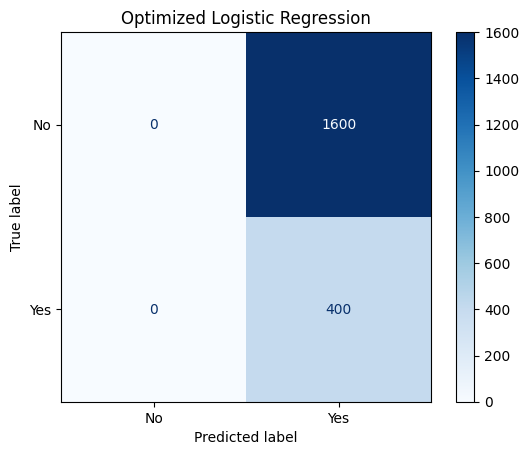

In [87]:
# ==========================================
# Improve Logistic Regression Performance
# 1. SMOTE
# 2. Feature Selection
# 3. Hyperparameter Tuning
# 4. Threshold Tuning
# ==========================================


# Pipeline
# Preprocessing → SMOTE → Feature Selection → Logistic Regression

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif, k=30)),
    ('classifier', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================
# Hyperparameter Grid
# ==========================================
param_grid = {
    'selector__k': [20, 30, 40, 'all'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# ==========================================
# Grid Search
# ==========================================
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train
grid.fit(X_train, y_train)

# ==========================================
# Best Model
# ==========================================
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

# ==========================================
# Predict Probabilities
# ==========================================
y_prob = best_model.predict_proba(X_test)[:, 1]

# ==========================================
# Threshold Tuning
# ==========================================
best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.91, 0.05):
    y_pred_temp = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_temp, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)

# ==========================================
# Final Prediction
# ==========================================
y_pred = (y_prob >= best_threshold).astype(int)

# ==========================================
# Final Evaluation
# ==========================================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))

# ==========================================
# Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Optimized Logistic Regression")
plt.show()

#Model Save

In [ ]:
# ==========================================
# 1. Save Final Model

import joblib

# যদি তোমার final model-এর নাম best_model হয়
joblib.dump(best_model, 'heart_disease_model.pkl')

print("Model saved successfully!")

In [ ]:
# 2. Load Saved Model
loaded_model = joblib.load('heart_disease_model.pkl')

print("Model loaded successfully!")

In [ ]:
# 3. Test on New Patient Data

# নতুন রোগীর তথ্য (কলাম নাম অবশ্যই X-এর সাথে একই হতে হবে)
new_patient = pd.DataFrame([{
    'Age': 55,
    'Gender': 'Male',
    'Blood Pressure': 145,
    'Cholesterol Level': 240,
    'Exercise Habits': 'Low',
    'Smoking': 'Yes',
    'Family Heart Disease': 'Yes',
    'Diabetes': 'Yes',
    'BMI': 31.5,
    'High Blood Pressure': 'Yes',
    'Low HDL Cholesterol': 'Yes',
    'High LDL Cholesterol': 'Yes',
    'Alcohol Consumption': 'Medium',
    'Stress Level': 'High',
    'Sleep Hours': 5,
    'Sugar Consumption': 'High',
    'Triglyceride Level': 220,
    'Fasting Blood Sugar': 145,
    'CRP Level': 4.8,
    'Homocysteine Level': 18.2
}])

# Predict class (0 = No, 1 = Yes)
prediction = loaded_model.predict(new_patient)[0]

# Predict probability
probability = loaded_model.predict_proba(new_patient)[0, 1]

# Convert to label
label = 'Yes' if prediction == 1 else 'No'

print("Predicted Heart Disease:", label)
print("Probability:", round(probability * 100, 2), "%")